# 01 — Pandas Introduction

**pandas** is the go-to Python library for working with tabular data (think: spreadsheets, CSVs, databases).

You'll learn:
- How to create and load DataFrames
- How to explore and filter data
- How to do basic statistics
- How to visualize data

Machine learning always starts with data — this notebook is your foundation.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print('Libraries loaded!')

Libraries loaded!


## 1. Creating a DataFrame

A **DataFrame** is a table — rows are samples, columns are features.

In [13]:
# Create a simple DataFrame from a dictionary
data = {
    'name':   ['Alice', 'Bob', 'Carol', 'Dave', 'Eve'],
    'age':    [25, 30, 35, 28, 22],
    'salary': [55000, 72000, 90000, 63000, 48000],
    'dept':   ['Engineering', 'Marketing', 'Engineering', 'Sales', 'Marketing'],
}

df = pd.DataFrame(data)
df

,name,age,salary,dept
0,Alice,25,55000,Engineering
1,Bob,30,72000,Marketing
2,Carol,35,90000,Engineering
3,Dave,28,63000,Sales
4,Eve,22,48000,Marketing


## 2. Exploring a DataFrame

These are the first things you run on any new dataset.

In [14]:
print('Shape (rows, columns):', df.shape)
print()
print('Column names:', df.columns.tolist())
print()
print('Data types:')
print(df.dtypes)

Shape (rows, columns): (5, 4)

Column names: ['name', 'age', 'salary', 'dept']

Data types:
name        str
age       int64
salary    int64
dept        str
dtype: object


In [15]:
# Summary statistics for numeric columns
df.describe()

,age,salary
count,5.000000,5.000000
mean,28.000000,65600.000000
std,4.949747,16318.700929
min,22.000000,48000.000000
25%,25.000000,55000.000000
50%,28.000000,63000.000000
75%,30.000000,72000.000000
max,35.000000,90000.000000


In [16]:
# Check for missing values
df.isnull().sum()

name      0
age       0
salary    0
dept      0
dtype: int64

## 3. Selecting and Filtering Data

In [17]:
# Select a single column
df['age']

0    25
1    30
2    35
3    28
4    22
Name: age, dtype: int64

In [18]:
# Select multiple columns
df[['name', 'salary']]

,name,salary
0,Alice,55000
1,Bob,72000
2,Carol,90000
3,Dave,63000
4,Eve,48000


In [19]:
# Filter rows: people with salary > 60000
df[df['salary'] > 60000]

,name,age,salary,dept
1,Bob,30,72000,Marketing
2,Carol,35,90000,Engineering
3,Dave,28,63000,Sales


In [20]:
# Filter by department
df[df['dept'] == 'Engineering']

,name,age,salary,dept
0,Alice,25,55000,Engineering
2,Carol,35,90000,Engineering


## 4. Aggregating and Grouping

In [28]:
# Average salary by department
df.groupby('dept')['salary'].mean()

dept
Engineering    72500.0
Marketing      60000.0
Sales          63000.0
Name: salary, dtype: float64

In [29]:
# Count of people per department
df['dept'].value_counts()

dept
Engineering    2
Marketing      2
Sales          1
Name: count, dtype: int64

## 5. Working with a Real Dataset

pandas can load CSVs directly from the web or disk. Let's use the classic **Iris** dataset.

In [38]:
from sklearn.datasets import load_iris

iris_data = load_iris(as_frame=True)
iris = iris_data.frame
iris.head(33)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [36]:
iris.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## 6. Basic Visualization

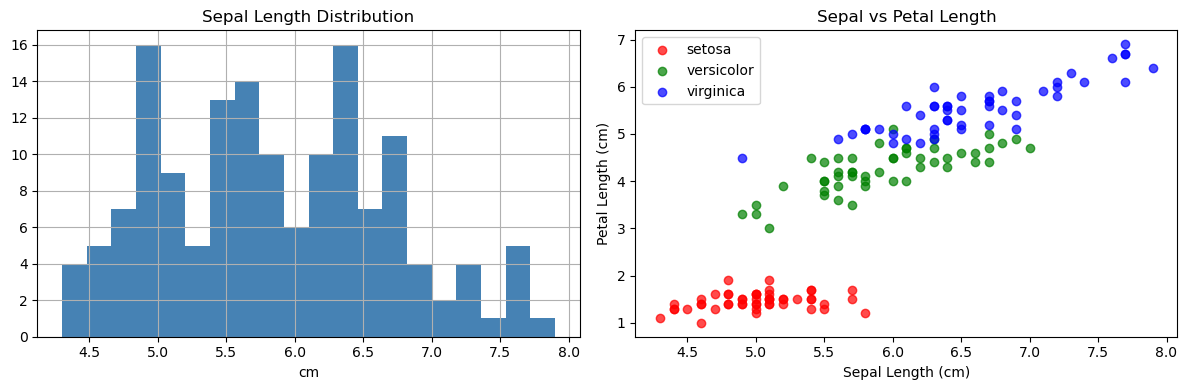


Notice how the three species cluster visually — this is what ML algorithms learn to separate!


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of sepal length
iris['sepal length (cm)'].hist(ax=axes[0], bins=20, color='steelblue')
axes[0].set_title('Sepal Length Distribution')
axes[0].set_xlabel('cm')

# Scatter plot: sepal length vs petal length, colored by species
colors = {0: 'red', 1: 'green', 2: 'blue'}
for species, group in iris.groupby('target'):
    axes[1].scatter(group['sepal length (cm)'], group['petal length (cm)'],
                    c=colors[species], label=iris_data.target_names[species], alpha=0.7)
axes[1].set_title('Sepal vs Petal Length')
axes[1].set_xlabel('Sepal Length (cm)')
axes[1].set_ylabel('Petal Length (cm)')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nNotice how the three species cluster visually — this is what ML algorithms learn to separate!')

## Summary

You now know how to:
- Create and load DataFrames
- Explore shape, dtypes, statistics, and missing values
- Filter and select rows/columns
- Group and aggregate
- Make basic plots

**Next:** `02_sklearn_basics.ipynb` — use this data to train your first ML model!